# Zeitreihenanalyse und Prognose der Verkaufszahlen: Store 85

## Forschungsfrage

Wie gut lassen sich die täglichen Verkaufszahlen von **Store 85** anhand historischer Verkäufe,
Kalendermerkmalen sowie vorab bekannten Aktions- und Feiertagsinformationen prognostizieren?

## Inhalt

1. **Explorative Datenanalyse (EDA)**
   - 1.1 Imports und Daten laden
   - 1.2 Datenqualität
   - 1.3 Verteilung der Verkaufszahlen
   - 1.4 Zeitliche Muster
2. **Zeitreihenanalyse**
   - 2.1 Trend und Saison
   - 2.2 Autokorrelation
   - 2.3 Anomalien
   - 2.4 Stationarität
3. **Feature Engineering**
   - 3.1 Auswahl der Merkmale
   - 3.2 Kalender-, Lag- und Rolling-Merkmale
   - 3.3 Zeitbasierte Aufteilung
4. **Prognosemodelle**
   - 4.1 Naive Baseline
   - 4.2 Prophet
   - 4.3 XGBoost
5. **Modellvergleich**
6. **Fazit**

## Methodischer Rahmen

- Prognosehorizont: die letzten **42 Tage** als Holdout-Periode.
- Keine zufällige Aufteilung: Zeitreihendaten werden chronologisch getrennt.
- Rolling-Merkmale verwenden ausschließlich vergangene Verkäufe (`shift(1)`).
- `Customers` wird nicht als Modellmerkmal verwendet, weil die Kundenzahl für zukünftige Tage
  zum Prognosezeitpunkt nicht bekannt ist.

## 1. Explorative Datenanalyse (EDA)

### 1.1 Imports und Daten laden

Für Store 85 werden Verkaufsdaten mit den Stammdaten des Geschäfts verbunden. Im weiteren Verlauf
bleiben nur Merkmale erhalten, die für diesen einzelnen Store inhaltlich relevant sind.

In [1]:
from pathlib import Path
import sys
import warnings

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import probplot
from sklearn.metrics import mean_absolute_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, kpss
from xgboost import XGBRegressor
from prophet import Prophet

warnings.filterwarnings("ignore", category=FutureWarning)
plt.style.use("seaborn-v0_8")
sns.set_palette("tab10")
pd.set_option("display.max_columns", 50)

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from config import DB_PATH

STORE_ID = 85
HOLDOUT_DAYS = 42

with duckdb.connect(str(DB_PATH), read_only=True) as con:
    sales = con.sql(f"SELECT * FROM raw_sales WHERE Store = {STORE_ID}").df()
    store = con.sql(f"SELECT * FROM raw_store WHERE Store = {STORE_ID}").df()

df = (
    sales.merge(store, on="Store", how="left")
    .sort_values("Date")
    .reset_index(drop=True)
)
df["Date"] = pd.to_datetime(df["Date"])

print(f"Store: {STORE_ID}")
print(f"Zeitraum: {df['Date'].min().date()} bis {df['Date'].max().date()}")
print(f"Beobachtungen: {len(df)}")
df.head()

Store: 85
Zeitraum: 2013-01-01 bis 2015-07-31
Beobachtungen: 942


/Users/vladimir/PycharmProjects/Rossmann/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,Date,Store,DayOfWeek,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,2013-01-01,85,2,4220,619,1,0,a,1,b,a,1870,10,2011,0,<NA>,<NA>,None
1,2013-01-02,85,3,6069,914,1,0,0,1,b,a,1870,10,2011,0,<NA>,<NA>,None
2,2013-01-03,85,4,5246,820,1,0,0,1,b,a,1870,10,2011,0,<NA>,<NA>,None
3,2013-01-04,85,5,5339,805,1,0,0,1,b,a,1870,10,2011,0,<NA>,<NA>,None
4,2013-01-05,85,6,5774,772,1,0,0,0,b,a,1870,10,2011,0,<NA>,<NA>,None


### 1.2 Datenqualität

Geprüft werden Vollständigkeit, doppelte Datumswerte und fachlich wichtige Sonderfälle. Fehlende
Werte in `Promo2SinceWeek`, `Promo2SinceYear` und `PromoInterval` sind hier erwartbar, weil Store 85
nicht am langfristigen `Promo2`-Programm teilnimmt.

In [2]:
quality_summary = pd.Series(
    {
        "Zeilen": len(df),
        "Eindeutige Datumswerte": df["Date"].nunique(),
        "Doppelte Datumswerte": df["Date"].duplicated().sum(),
        "Fehlende Kalendertage": (
            pd.date_range(df["Date"].min(), df["Date"].max(), freq="D")
            .difference(df["Date"])
            .size
        ),
        "Geschlossen (Open = 0)": (df["Open"] == 0).sum(),
        "Nullverkäufe": (df["Sales"] == 0).sum(),
        "Nullkunden": (df["Customers"] == 0).sum(),
    },
    name="Wert",
)
quality_summary.to_frame()

,Wert
Zeilen,942
Eindeutige Datumswerte,942
Doppelte Datumswerte,0
Fehlende Kalendertage,0
Geschlossen (Open = 0),0
Nullverkäufe,0
Nullkunden,0


In [3]:
missing_values = (
    df.isna()
    .sum()
    .rename("Fehlende Werte")
    .to_frame()
    .assign(Anteil=lambda x: (x["Fehlende Werte"] / len(df)).round(3))
)
missing_values[missing_values["Fehlende Werte"] > 0]

,Fehlende Werte,Anteil
Promo2SinceWeek,942,1.0
Promo2SinceYear,942,1.0
PromoInterval,942,1.0


In [4]:
constant_columns = [
    column for column in df.columns
    if df[column].nunique(dropna=False) <= 1
]
print("Konstante Merkmale:", constant_columns)

df.dtypes.to_frame("Datentyp")

Konstante Merkmale: ['Store', 'Open', 'StoreType', 'Assortment', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval']


,Datentyp
Date,datetime64[us]
Store,int64
DayOfWeek,int64
Sales,int64
Customers,int64
Open,int64
Promo,int64
StateHoliday,object
SchoolHoliday,int64
StoreType,object


### 1.3 Verteilung der Verkaufszahlen

Histogramm, Log-Transformation und QQ-Plot zeigen, ob starke Schiefe oder auffällige Randbereiche
vorliegen. Die Log-Transformation wird nur diagnostisch betrachtet; die Modelle prognostizieren
weiterhin Verkäufe in Originaleinheiten.

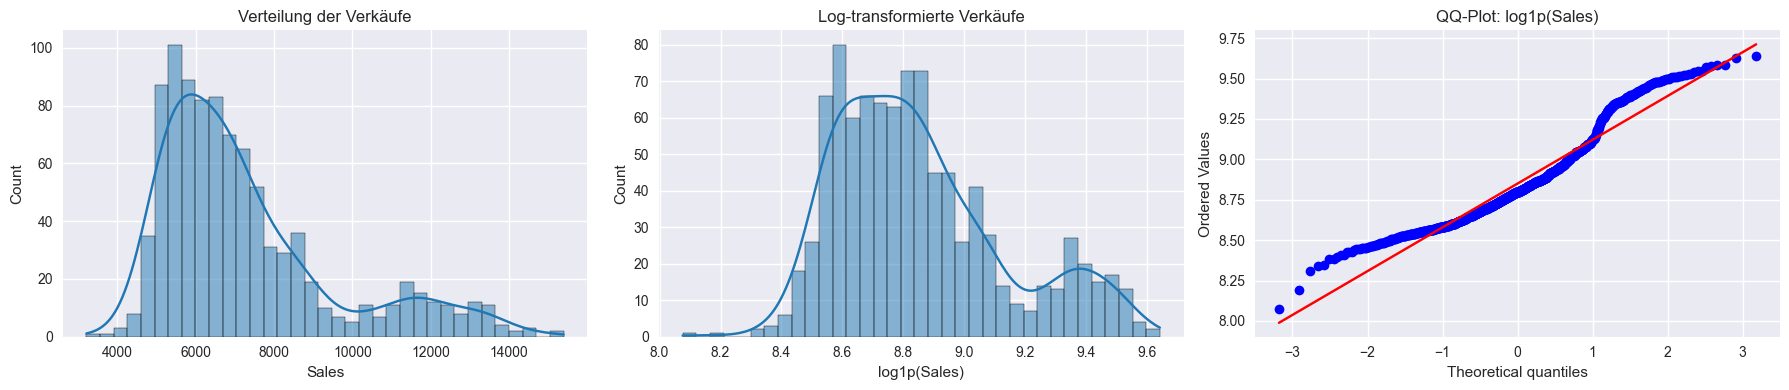

,count,mean,std,min,25%,50%,75%,max
Sales,942.0,7272.454352,2272.861165,3215.0,5645.5,6622.0,8066.5,15386.0


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

sns.histplot(df["Sales"], bins=35, kde=True, ax=axes[0])
axes[0].set_title("Verteilung der Verkäufe")
axes[0].set_xlabel("Sales")

log_sales = np.log1p(df["Sales"])
sns.histplot(log_sales, bins=35, kde=True, ax=axes[1])
axes[1].set_title("Log-transformierte Verkäufe")
axes[1].set_xlabel("log1p(Sales)")

probplot(log_sales, dist="norm", plot=axes[2])
axes[2].set_title("QQ-Plot: log1p(Sales)")

plt.tight_layout()
plt.show()

df["Sales"].describe().to_frame().T

### 1.4 Zeitliche Muster

Für Tages-, Wochen- und Monatsmuster werden Mittelwerte der Verkäufe betrachtet. Zusätzlich werden
vorab bekannte Geschäftsinformationen geprüft: reguläre Promotionen und Feiertage.

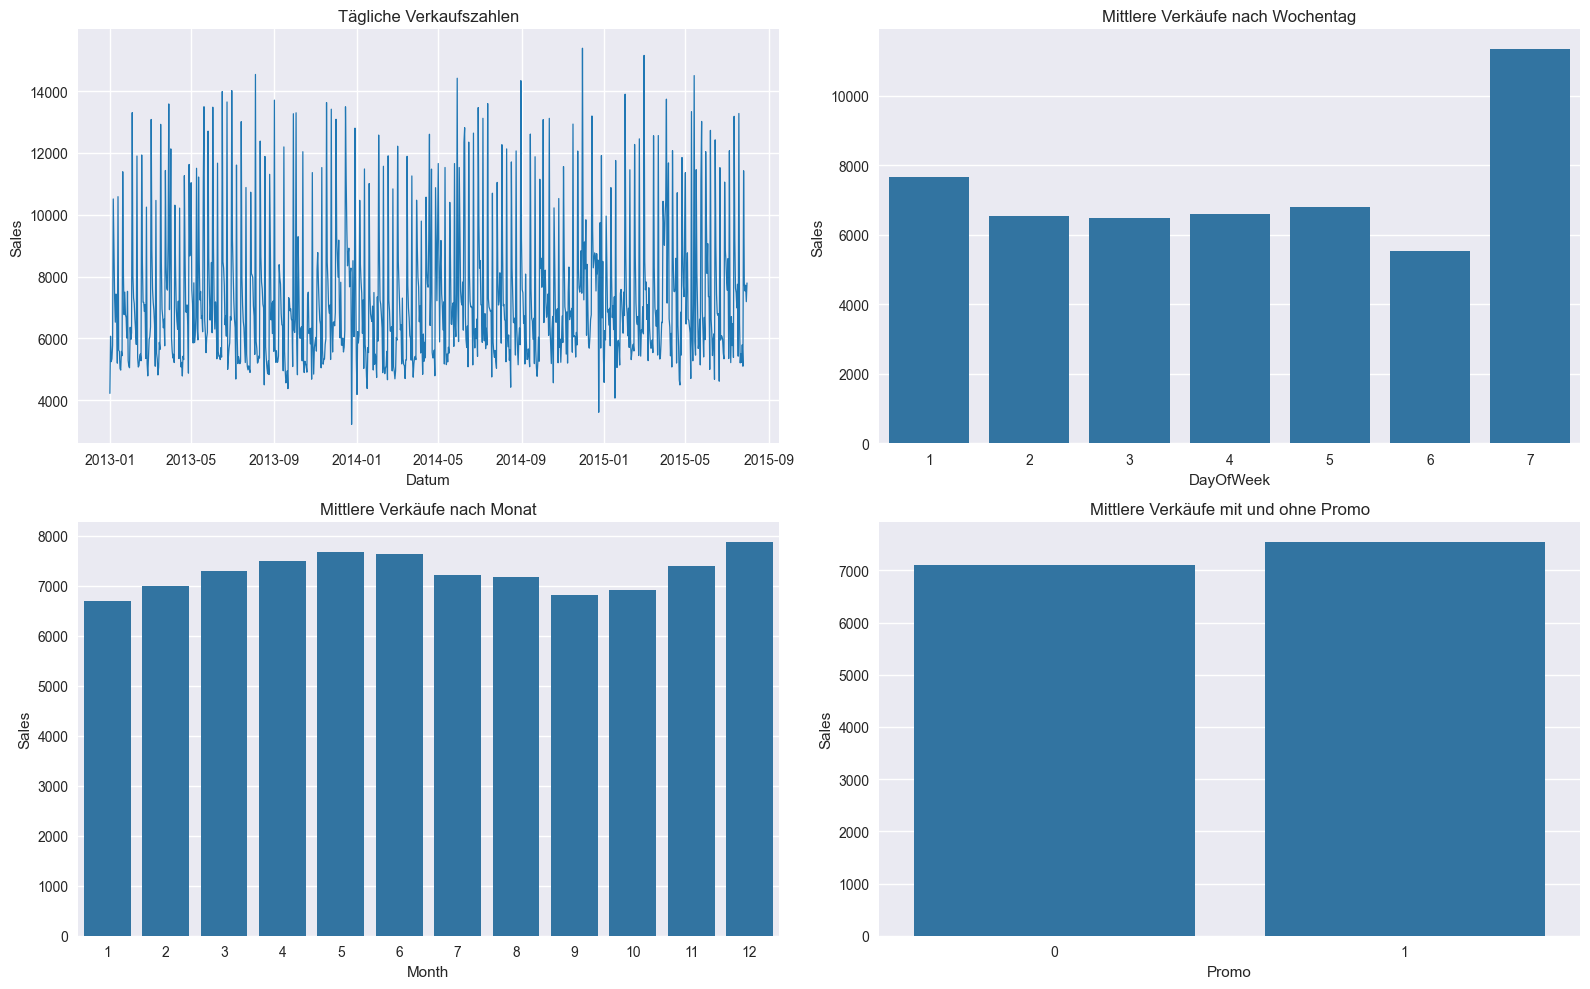

In [6]:
eda = df.copy()
eda["Month"] = eda["Date"].dt.month

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0, 0].plot(eda["Date"], eda["Sales"], linewidth=0.9)
axes[0, 0].set_title("Tägliche Verkaufszahlen")
axes[0, 0].set_xlabel("Datum")
axes[0, 0].set_ylabel("Sales")

sns.barplot(data=eda, x="DayOfWeek", y="Sales", estimator=np.mean, errorbar=None, ax=axes[0, 1])
axes[0, 1].set_title("Mittlere Verkäufe nach Wochentag")

sns.barplot(data=eda, x="Month", y="Sales", estimator=np.mean, errorbar=None, ax=axes[1, 0])
axes[1, 0].set_title("Mittlere Verkäufe nach Monat")

sns.barplot(data=eda, x="Promo", y="Sales", estimator=np.mean, errorbar=None, ax=axes[1, 1])
axes[1, 1].set_title("Mittlere Verkäufe mit und ohne Promo")

plt.tight_layout()
plt.show()

In [7]:
business_effects = pd.concat(
    {
        "Promo": df.groupby("Promo")["Sales"].agg(["count", "mean"]),
        "StateHoliday": df.groupby("StateHoliday")["Sales"].agg(["count", "mean"]),
        "SchoolHoliday": df.groupby("SchoolHoliday")["Sales"].agg(["count", "mean"]),
    },
    names=["Merkmal", "Ausprägung"],
)
business_effects.round(2)

count      mean
Merkmal       Ausprägung                 
Promo         0             582   7100.61
              1             360   7550.27
StateHoliday  0             918   7178.97
              a              14  10939.14
              b               6  12534.00
              c               4   8001.00
SchoolHoliday 0             769   7351.43
              1             173   6921.40

## 2. Zeitreihenanalyse

### 2.1 Trend und Saison

Die Zeitreihe wird um einen 30-Tage-Rolling-Mean ergänzt. Eine robuste STL-Zerlegung mit
Periodenlänge `7` isoliert die besonders relevante Wochensaisonalität.

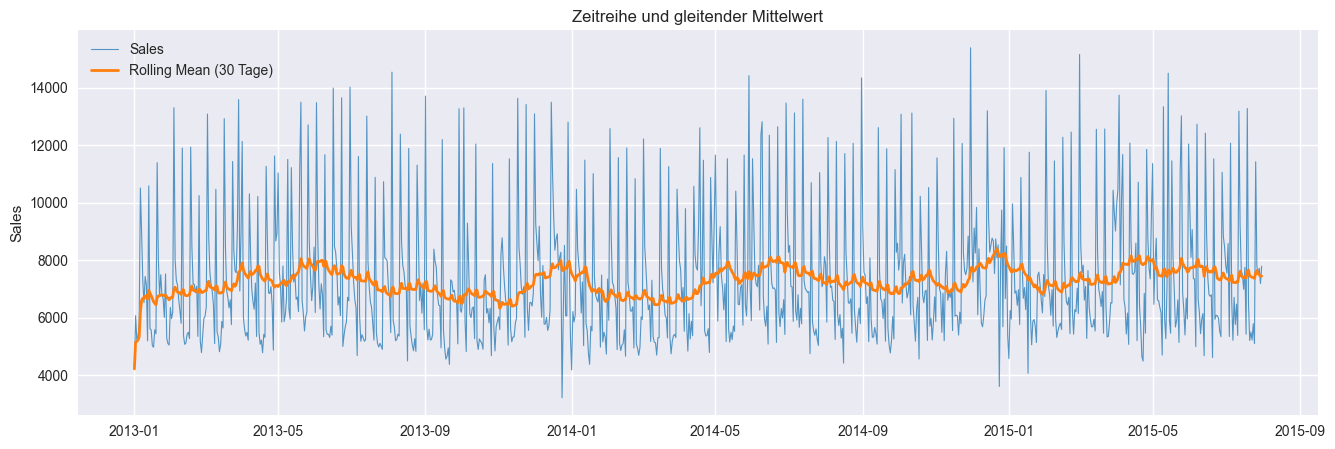

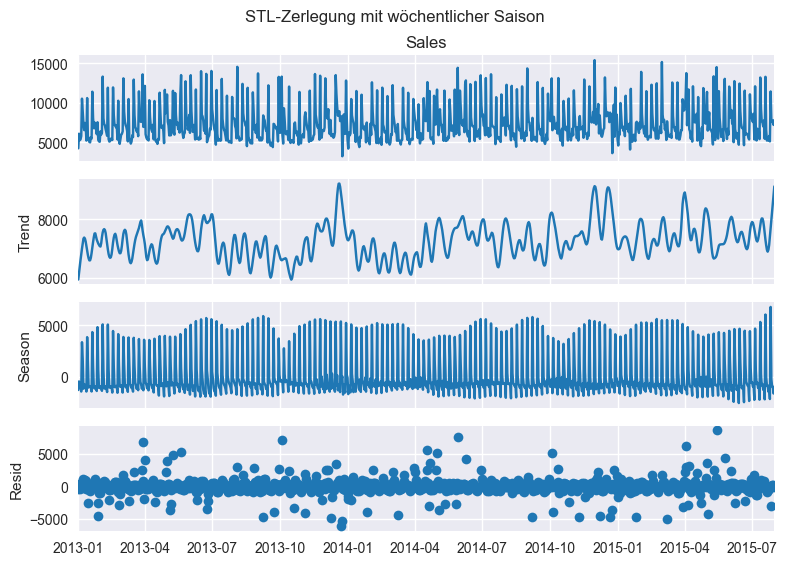

In [8]:
ts = df.set_index("Date")["Sales"].asfreq("D")
rolling_mean_30 = ts.rolling(window=30, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(ts.index, ts, label="Sales", linewidth=0.8, alpha=0.75)
ax.plot(rolling_mean_30.index, rolling_mean_30, label="Rolling Mean (30 Tage)", linewidth=2)
ax.set_title("Zeitreihe und gleitender Mittelwert")
ax.set_ylabel("Sales")
ax.legend()
plt.show()

stl_result = STL(ts, period=7, robust=True).fit()
stl_result.plot()
plt.suptitle("STL-Zerlegung mit wöchentlicher Saison", y=1.02)
plt.show()

### 2.2 Autokorrelation

ACF und PACF helfen bei der Auswahl sinnvoller Lag-Merkmale. Besondere Aufmerksamkeit gilt den
Wochenabständen `7`, `14` und `28`.

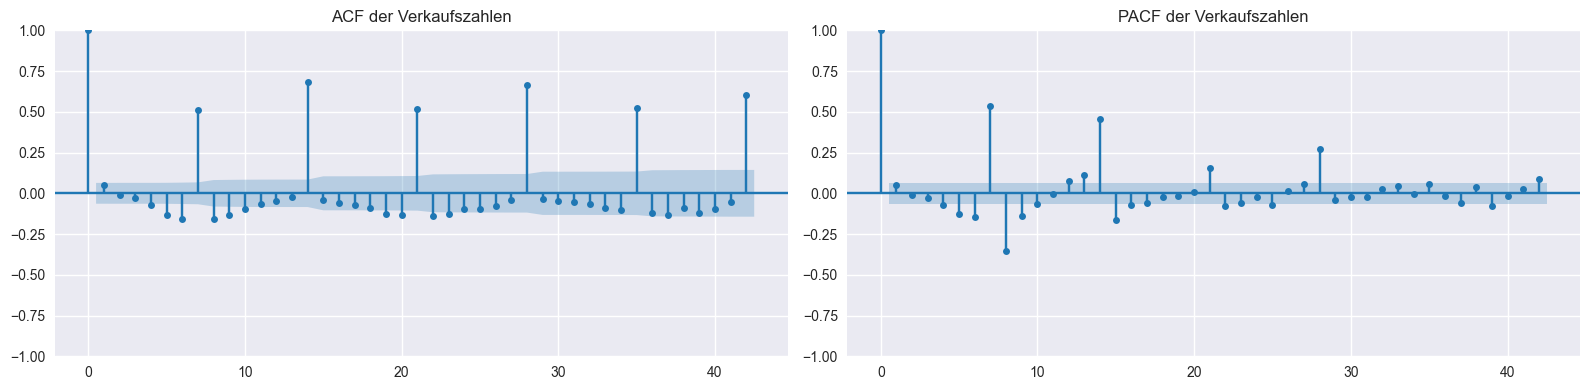

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
plot_acf(ts, lags=42, ax=axes[0])
axes[0].set_title("ACF der Verkaufszahlen")
plot_pacf(ts, lags=42, method="ywm", ax=axes[1])
axes[1].set_title("PACF der Verkaufszahlen")
plt.tight_layout()
plt.show()

### 2.3 Anomalien

Ein Rolling Z-Score markiert Tage, deren Verkäufe stark vom vorherigen 30-Tage-Fenster abweichen.
Diese Punkte werden nicht automatisch entfernt: Feiertage und Promotionen können fachlich
plausible Spitzen verursachen.

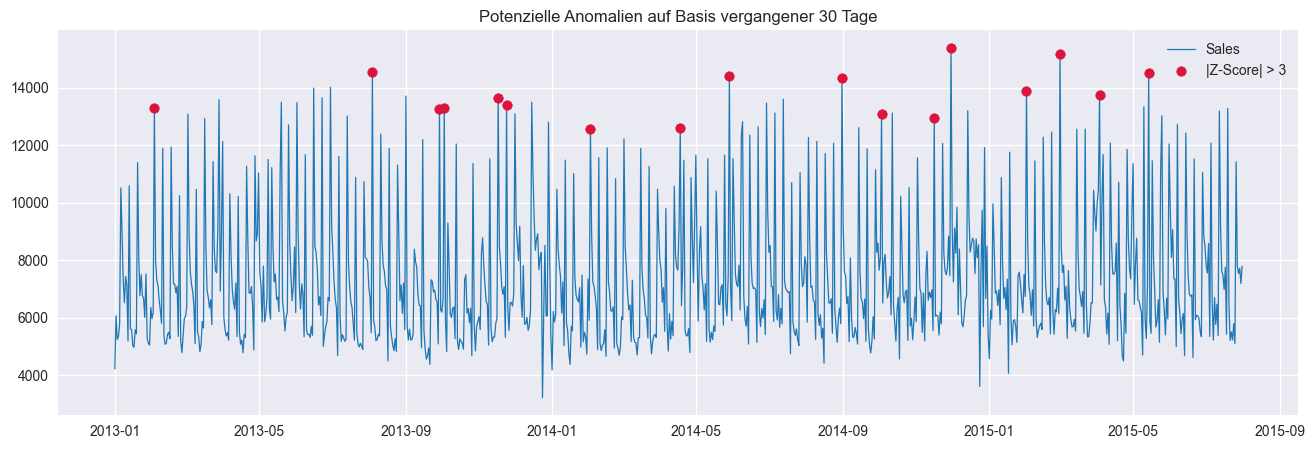

,Date,Sales,Promo,StateHoliday,rolling_zscore,is_anomaly
761,2015-02-01,13899,0,0,4.282710,True
320,2013-11-17,13629,0,0,4.240558,True
698,2014-11-30,15386,0,0,4.211495,True
33,2013-02-03,13302,0,0,3.825364,True
684,2014-11-16,12932,0,0,3.684934,True
513,2014-05-29,14415,0,a,3.606992,True
215,2013-08-04,14538,0,0,3.544034,True
789,2015-03-01,15153,0,0,3.467928,True
275,2013-10-03,13297,0,a,3.387732,True
607,2014-08-31,14336,0,0,3.321089,True


In [10]:
anomalies = df[["Date", "Sales", "Promo", "StateHoliday"]].copy()
history_mean = anomalies["Sales"].shift(1).rolling(30, min_periods=14).mean()
history_std = anomalies["Sales"].shift(1).rolling(30, min_periods=14).std()
anomalies["rolling_zscore"] = (anomalies["Sales"] - history_mean) / history_std
anomalies["is_anomaly"] = anomalies["rolling_zscore"].abs() > 3

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(anomalies["Date"], anomalies["Sales"], linewidth=0.9, label="Sales")
flagged = anomalies[anomalies["is_anomaly"]]
ax.scatter(flagged["Date"], flagged["Sales"], color="crimson", label="|Z-Score| > 3", zorder=3)
ax.set_title("Potenzielle Anomalien auf Basis vergangener 30 Tage")
ax.legend()
plt.show()

flagged.sort_values("rolling_zscore", key=np.abs, ascending=False).head(15)

### 2.4 Stationarität

ADF und KPSS werden ergänzend berichtet. Für XGBoost ist Stationarität keine harte Voraussetzung;
die Tests helfen dennoch bei der Interpretation der Reihe.

In [11]:
def stationarity_tests(series):
    adf_result = adfuller(series, autolag="AIC")
    kpss_result = kpss(series, regression="c", nlags="auto")
    return pd.DataFrame(
        {
            "Test": ["ADF", "KPSS"],
            "Statistik": [adf_result[0], kpss_result[0]],
            "p-Wert": [adf_result[1], kpss_result[1]],
            "Nullhypothese": [
                "Nicht stationär",
                "Stationär",
            ],
        }
    )

stationarity_tests(ts).round(4)

,Test,Statistik,p-Wert,Nullhypothese
0,ADF,-5.6609,0.0000,Nicht stationär
1,KPSS,0.5231,0.0365,Stationär


## 3. Feature Engineering

### 3.1 Auswahl der Merkmale

Verwendet werden ausschließlich Merkmale, die variieren und zum Prognosezeitpunkt verfügbar sind.

| Gruppe | Verwendete Merkmale | Begründung |
|---|---|---|
| Kalender | `DayOfWeek`, `Month`, `Week`, `DayOfMonth` | Vorab bekannt, bilden saisonale Muster ab |
| Geschäft | `Promo`, `SchoolHoliday`, `StateHoliday` | Vorab bekannt und fachlich relevant |
| Historie | `lag_1`, `lag_7`, `lag_14`, `lag_28` | Nutzen ausschließlich vergangene Verkäufe |
| Historie | `roll_mean_7`, `roll_mean_30`, `roll_std_7` | Nutzen ausschließlich vergangene Verkäufe |

Bewusst ausgeschlossen werden:

- `Customers`: für die Zukunft nicht bekannt und daher potenzielle Datenleckage.
- `Store`, `Open`, `Promo2`, `StoreType`, `Assortment`, Wettbewerbsmerkmale: für Store 85 konstant.
- `Promo2SinceWeek`, `Promo2SinceYear`, `PromoInterval`: vollständig leer, da `Promo2 = 0`.

In [12]:
excluded_columns = [
    "Customers",
    "Store",
    "Open",
    "Promo2",
    "StoreType",
    "Assortment",
    "CompetitionDistance",
    "CompetitionOpenSinceMonth",
    "CompetitionOpenSinceYear",
    "Promo2SinceWeek",
    "Promo2SinceYear",
    "PromoInterval",
]

pd.DataFrame(
    {
        "Ausgeschlossenes Merkmal": excluded_columns,
        "Im Datensatz konstant oder leer": [
            df[column].nunique(dropna=False) <= 1 for column in excluded_columns
        ],
    }
)

,Ausgeschlossenes Merkmal,Im Datensatz konstant oder leer
0,Customers,False
1,Store,True
2,Open,True
3,Promo2,True
4,StoreType,True
5,Assortment,True
6,CompetitionDistance,True
7,CompetitionOpenSinceMonth,True
8,CompetitionOpenSinceYear,True
9,Promo2SinceWeek,True


### 3.2 Kalender-, Lag- und Rolling-Merkmale

Bei Rolling-Fenstern wird zuerst um einen Tag verschoben. Dadurch fließt der Zielwert des
vorherzusagenden Tages nicht in seine eigenen Merkmale ein.

In [13]:
def create_features(data):
    features = data[
        ["Date", "Sales", "Promo", "SchoolHoliday", "StateHoliday"]
    ].copy()

    features["DayOfWeek"] = features["Date"].dt.dayofweek + 1
    features["Month"] = features["Date"].dt.month
    features["Week"] = features["Date"].dt.isocalendar().week.astype(int)
    features["DayOfMonth"] = features["Date"].dt.day

    for lag in [1, 7, 14, 28]:
        features[f"lag_{lag}"] = features["Sales"].shift(lag)

    sales_history = features["Sales"].shift(1)
    features["roll_mean_7"] = sales_history.rolling(7).mean()
    features["roll_mean_30"] = sales_history.rolling(30).mean()
    features["roll_std_7"] = sales_history.rolling(7).std()

    features = pd.get_dummies(
        features,
        columns=["StateHoliday"],
        prefix="StateHoliday",
        dtype=int,
    )
    return features


model_df = create_features(df).dropna().reset_index(drop=True)
model_df.head()

,Date,Sales,Promo,SchoolHoliday,DayOfWeek,Month,Week,DayOfMonth,lag_1,lag_7,lag_14,lag_28,roll_mean_7,roll_mean_30,roll_std_7,StateHoliday_0,StateHoliday_a,StateHoliday_b,StateHoliday_c
0,2013-01-31,6358,0,0,4,1,5,31,5050.0,6768.0,4973.0,5246.0,6058.000000,6621.800000,962.600644,1,0,0,0
1,2013-02-01,5967,0,0,5,2,5,1,6358.0,6672.0,5579.0,5339.0,5999.428571,6693.066667,923.894449,1,0,0,0
2,2013-02-02,6180,0,0,6,2,5,2,5967.0,6010.0,5440.0,5774.0,5898.714286,6689.666667,875.517126,1,0,0,0
3,2013-02-03,13302,0,0,7,2,5,3,6180.0,7522.0,11390.0,10509.0,5923.000000,6720.800000,881.456182,1,0,0,0
4,2013-02-04,8018,1,1,1,2,6,4,13302.0,5284.0,8065.0,8990.0,6748.714286,6986.233333,2937.742938,1,0,0,0


In [14]:
feature_columns = [
    column for column in model_df.columns
    if column not in {"Date", "Sales"}
]

print(f"Modellzeilen nach Lag-Bildung: {len(model_df)}")
print("Verwendete Modellmerkmale:")
print(feature_columns)

Modellzeilen nach Lag-Bildung: 912
Verwendete Modellmerkmale:
['Promo', 'SchoolHoliday', 'DayOfWeek', 'Month', 'Week', 'DayOfMonth', 'lag_1', 'lag_7', 'lag_14', 'lag_28', 'roll_mean_7', 'roll_mean_30', 'roll_std_7', 'StateHoliday_0', 'StateHoliday_a', 'StateHoliday_b', 'StateHoliday_c']


### 3.3 Zeitbasierte Aufteilung

Die letzten `42` Tage bilden die Holdout-Periode. Die Auswertung entspricht einer täglichen
One-Step-Ahead-Prognose: Für jeden Prognosetag sind die tatsächlich beobachteten Verkäufe der
vorherigen Tage bereits bekannt. Für eine echte rekursive 42-Tage-Prognose müssten vorhergesagte
Werte schrittweise in die Lag-Merkmale zurückgeführt werden.

In [15]:
split_date = model_df["Date"].max() - pd.Timedelta(days=HOLDOUT_DAYS - 1)
train_df = model_df[model_df["Date"] < split_date].copy()
test_df = model_df[model_df["Date"] >= split_date].copy()

X_train = train_df[feature_columns]
y_train = train_df["Sales"]
X_test = test_df[feature_columns]
y_test = test_df["Sales"]

print(f"Training: {train_df['Date'].min().date()} bis {train_df['Date'].max().date()} ({len(train_df)} Tage)")
print(f"Holdout:  {test_df['Date'].min().date()} bis {test_df['Date'].max().date()} ({len(test_df)} Tage)")

Training: 2013-01-31 bis 2015-06-19 (870 Tage)
Holdout:  2015-06-20 bis 2015-07-31 (42 Tage)


## 4. Prognosemodelle

### Bewertungsmetriken

- **MAE**: mittlere absolute Abweichung in Verkaufseinheiten.
- **MAPE**: mittlere prozentuale Abweichung.
- **WMAPE**: absolute Gesamtabweichung relativ zum Verkaufsvolumen; im Retail-Kontext gut lesbar.

In [16]:
def regression_metrics(actual, predicted):
    actual = np.asarray(actual)
    predicted = np.asarray(predicted)
    return {
        "MAE": mean_absolute_error(actual, predicted),
        "MAPE (%)": np.mean(np.abs((actual - predicted) / actual)) * 100,
        "WMAPE (%)": np.sum(np.abs(actual - predicted)) / np.sum(np.abs(actual)) * 100,
    }


results = []
predictions = test_df[["Date", "Sales"]].rename(columns={"Sales": "Actual"}).copy()

### 4.1 Naive Baseline

Die Baseline übernimmt den Verkaufswert desselben Wochentags der Vorwoche (`lag_7`). Ein
komplexeres Modell sollte diese einfache, aber starke Referenz schlagen.

In [17]:
predictions["Naive_lag_7"] = test_df["lag_7"].to_numpy()
results.append(
    {
        "Modell": "Naive lag_7",
        **regression_metrics(predictions["Actual"], predictions["Naive_lag_7"]),
    }
)
pd.DataFrame(results).round(2)

,Modell,MAE,MAPE (%),WMAPE (%)
0,Naive lag_7,1544.36,22.17,20.88


### 4.2 Prophet

Prophet ist optional. Falls die Bibliothek in der aktiven Python-Umgebung installiert ist, wird
ein Modell mit den vorab bekannten Regressoren `Promo`, `SchoolHoliday` und Feiertagsindikatoren
trainiert. Andernfalls wird der Abschnitt übersprungen und transparent dokumentiert.

In [18]:
try:
    from prophet import Prophet

    prophet_available = True
except ImportError:
    prophet_available = False
    print("Prophet ist nicht installiert. Der Prophet-Vergleich wird übersprungen.")

In [19]:
if prophet_available:
    prophet_regressors = [
        "Promo",
        "SchoolHoliday",
        *[column for column in feature_columns if column.startswith("StateHoliday_")],
    ]

    prophet_train = train_df[["Date", "Sales", *prophet_regressors]].rename(
        columns={"Date": "ds", "Sales": "y"}
    )
    prophet_test = test_df[["Date", *prophet_regressors]].rename(columns={"Date": "ds"})

    prophet_model = Prophet(
        weekly_seasonality=True,
        yearly_seasonality=True,
        daily_seasonality=False,
    )
    for regressor in prophet_regressors:
        prophet_model.add_regressor(regressor)

    prophet_model.fit(prophet_train)
    predictions["Prophet"] = prophet_model.predict(prophet_test)["yhat"].to_numpy()
    results.append(
        {
            "Modell": "Prophet",
            **regression_metrics(predictions["Actual"], predictions["Prophet"]),
        }
    )
    display(pd.DataFrame(results).round(2))
else:
    print("Kein Prophet-Ergebnis verfügbar.")

14:19:19 - cmdstanpy - INFO - Chain [1] start processing


14:19:19 - cmdstanpy - INFO - Chain [1] done processing


/Users/vladimir/PycharmProjects/Rossmann/.venv/lib/python3.9/site-packages/prophet/forecaster.py:1421: RuntimeWarning: divide by zero encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Users/vladimir/PycharmProjects/Rossmann/.venv/lib/python3.9/site-packages/prophet/forecaster.py:1421: RuntimeWarning: overflow encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Users/vladimir/PycharmProjects/Rossmann/.venv/lib/python3.9/site-packages/prophet/forecaster.py:1421: RuntimeWarning: invalid value encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Users/vladimir/PycharmProjects/Rossmann/.venv/lib/python3.9/site-packages/prophet/forecaster.py:1565: RuntimeWarning: divide by zero encountered in matmul
  Xb_a = np.matmul(seasonal_features.values,
/Users/vladimir/PycharmProjects/Rossmann/.venv/lib/python3.9/site-packages/prophet/forecaster.py:1565: RuntimeWarning: overflow encountered in matmul
  Xb_a = np.matmul(seasonal_features.values,
/Users/vladimir/P

,Modell,MAE,MAPE (%),WMAPE (%)
0,Naive lag_7,1544.36,22.17,20.88
1,Prophet,467.04,6.76,6.32


### 4.3 XGBoost

XGBoost nutzt Kalenderinformationen, bekannte Geschäftsinformationen sowie historische Lag- und
Rolling-Merkmale. Die Modellkonfiguration ist bewusst kompakt und reproduzierbar.

In [20]:
xgb_model = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=500,
    learning_rate=0.03,
    max_depth=4,
    min_child_weight=3,
    subsample=0.85,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=4,
)
xgb_model.fit(X_train, y_train)

predictions["XGBoost"] = xgb_model.predict(X_test)
results.append(
    {
        "Modell": "XGBoost",
        **regression_metrics(predictions["Actual"], predictions["XGBoost"]),
    }
)
pd.DataFrame(results).round(2)

,Modell,MAE,MAPE (%),WMAPE (%)
0,Naive lag_7,1544.36,22.17,20.88
1,Prophet,467.04,6.76,6.32
2,XGBoost,458.39,6.29,6.20


## 5. Modellvergleich

Die Modelle werden auf derselben Holdout-Periode verglichen. Zusätzlich zeigt die Grafik die
tatsächlichen und prognostizierten Verkaufswerte im Zeitverlauf.

In [21]:
comparison = (
    pd.DataFrame(results)
    .sort_values("MAE")
    .reset_index(drop=True)
)
comparison.round(2)

,Modell,MAE,MAPE (%),WMAPE (%)
0,XGBoost,458.39,6.29,6.20
1,Prophet,467.04,6.76,6.32
2,Naive lag_7,1544.36,22.17,20.88


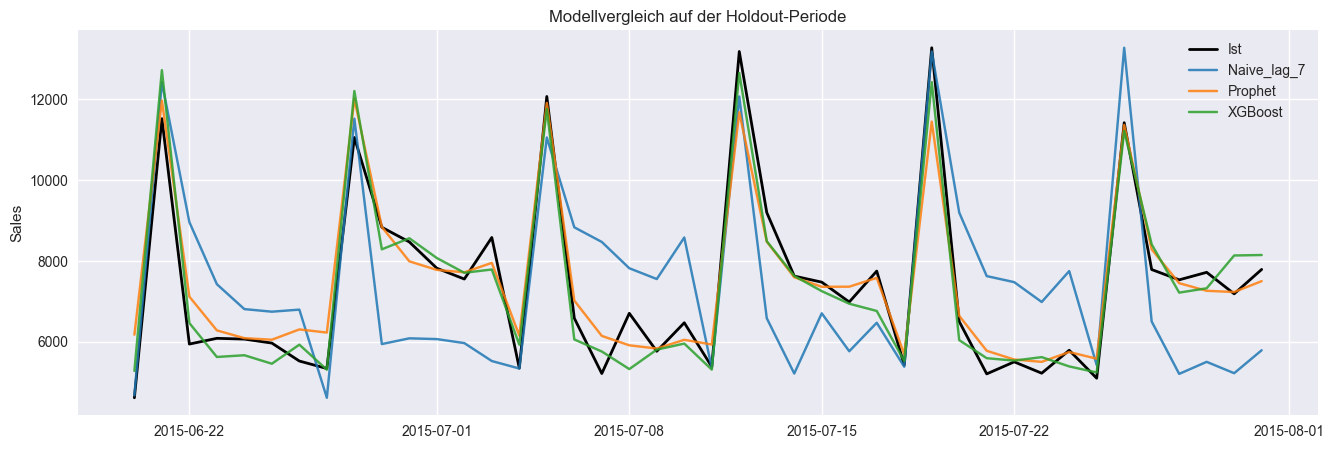

In [22]:
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(predictions["Date"], predictions["Actual"], label="Ist", linewidth=2, color="black")

for model_name in ["Naive_lag_7", "Prophet", "XGBoost"]:
    if model_name in predictions.columns:
        ax.plot(predictions["Date"], predictions[model_name], label=model_name, alpha=0.85)

ax.set_title("Modellvergleich auf der Holdout-Periode")
ax.set_ylabel("Sales")
ax.legend()
plt.show()

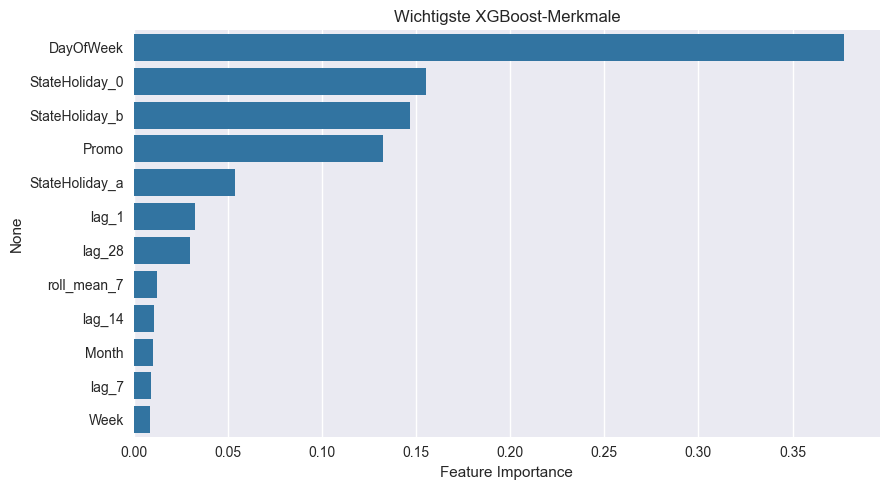

,Importance
DayOfWeek,0.3776
StateHoliday_0,0.1555
StateHoliday_b,0.1470
Promo,0.1323
StateHoliday_a,0.0540
lag_1,0.0327
lag_28,0.0299
roll_mean_7,0.0122
lag_14,0.0110
Month,0.0103


In [23]:
feature_importance = (
    pd.Series(xgb_model.feature_importances_, index=feature_columns, name="Importance")
    .sort_values(ascending=False)
    .head(12)
)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=feature_importance.values, y=feature_importance.index, ax=ax)
ax.set_title("Wichtigste XGBoost-Merkmale")
ax.set_xlabel("Feature Importance")
plt.tight_layout()
plt.show()

feature_importance.to_frame().round(4)

## 6. Fazit

Die Untersuchung beantwortet die Forschungsfrage anhand eines zeitbasierten Holdouts:

1. Store 85 besitzt einen vollständigen täglichen Zeitverlauf ohne Schließtage oder Nullverkäufe.
2. Die Verkäufe zeigen eine deutliche Wochensaisonalität. Deshalb ist `lag_7` eine sinnvolle
   Referenz und ein wichtiges Modellmerkmal.
3. Für die Prognose werden nur variable und zum Prognosezeitpunkt verfügbare Merkmale genutzt.
   Insbesondere bleibt `Customers` ausgeschlossen.
4. Der Vergleich bewertet Naive Baseline, optional Prophet und XGBoost anhand identischer
   Holdout-Daten.
5. Für einen produktiven Mehrtagesforecast ist als nächster methodischer Schritt eine rekursive
   oder direkte Multi-Step-Prognose mit Walk-Forward-Validierung erforderlich.

In [24]:
best_model = comparison.iloc[0]
print(
    f"Bestes verfügbares Modell: {best_model['Modell']} | "
    f"MAE: {best_model['MAE']:.2f} | "
    f"WMAPE: {best_model['WMAPE (%)']:.2f}%"
)

Bestes verfügbares Modell: XGBoost | MAE: 458.39 | WMAPE: 6.20%
